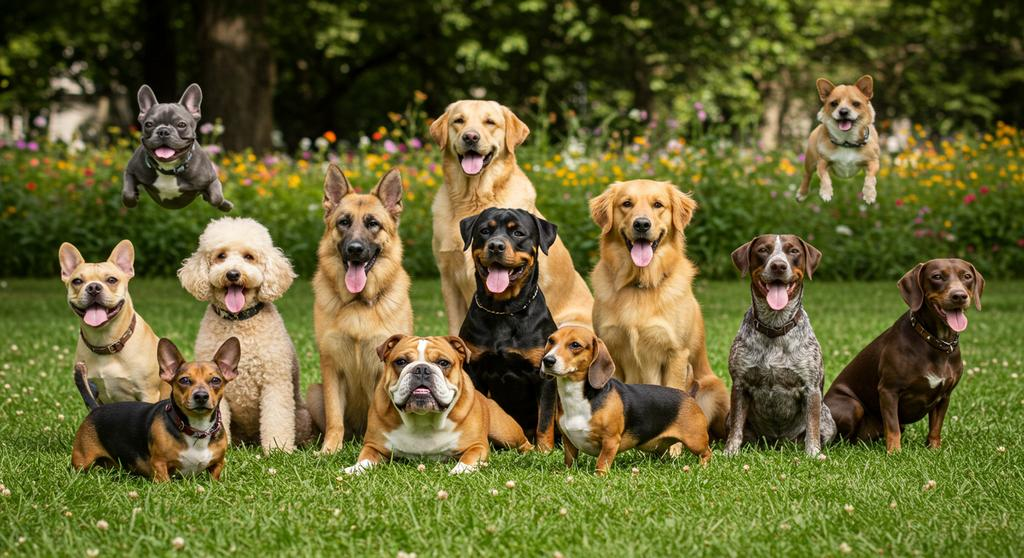

# **Dog Breed Classification: Xception**

This project focuses on classifying dog breeds using deep learning and transfer learning techniques. The images used for the dataset were obtained through Bing image search and organized by breed.
The goal is to build an image classification system capable of identifying different dog breeds from images. The approach uses pretrained models as feature extractors combined with machine learning classifiers.

### **Dog Breeds Covered**
The dataset contains images from the following dog breeds, each class will contain images representing the corresponding breed, which will be used to train and evaluate the classification models:

- **Pekingese**
- **Husky**
- **Bulldog**
- **Pitbull**
- **Beagle**



### **1) Load Libraries**

This code imports essential libraries for image processing, deep learning, and visualization. Below is a description of each library and its purpose:

- **`numpy`**: Used to handle multidimensional arrays and perform mathematical computations.
- **`matplotlib.pyplot`**: Allows effective visualization of graphs and images.
- **`glob`**: Helps search for files in the system using defined patterns.
- **`cv2` (OpenCV)**: A library used to load, process, and transform images.
- **`os`**: Provides tools to manage system paths and files.
- **`seaborn`**: Facilitates the creation of statistical visualizations.
- **`keras.models`**: Includes two ways to build models: `Sequential`, for linear architectures, and `Model`, for more complex architectures.
- **Keras layers**:
  - **`Dense`**: Adds fully connected layers to the model.
  - **`Flatten`**: Converts multidimensional data into a one-dimensional vector.
  - **`Conv2D`**: Extracts spatial features from images.
  - **`MaxPooling2D`**: Reduces the dimensionality of feature maps by selecting the most important values.
  - **`BatchNormalization`**: Normalizes network activations to accelerate training.
- **`VGG16`**: A widely used pretrained Keras model for transfer learning, where its layers are used as a feature extractor for custom tasks.

Overall, this code sets up a robust environment for developing and evaluating deep learning models for image-related tasks.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2

from keras.models import Model, Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization
import os
import seaborn as sns
from tensorflow.keras.applications import Xception
from sklearn.model_selection import train_test_split

### **2) Training Data Capture and Processing**

This code loads and processes training images from a specific directory, storing both the images and their corresponding labels in arrays for use in deep learning models.

1. **Initialization**: The lists `train_images` and `train_labels` are created to store the processed images and their class labels.
2. **Directory traversal**: All folders inside the training directory are explored, and the name of each folder is used as the corresponding label (`label`).
3. **Image loading**: Inside each folder, images with the `.jpg` extension are searched for. The images are loaded using `cv2.imread`. If an image cannot be loaded, an error message is printed and the file is skipped.
4. **Image processing**: Each loaded image is resized to a uniform size defined by `SIZE` and converted from BGR format (the default in OpenCV) to RGB, which is the standard format for neural networks.
5. **Storage and conversion**: The processed images are stored in the `train_images` list and their labels in `train_labels`. Finally, both lists are converted into NumPy arrays (`np.array`) to facilitate their use in deep learning models.


#### **2.1) Load Data**

In [1]:
SIZE_Xception = 299  #Resize images

According to the documentation, when using **Xception** with `include_top=False`, the input image must have **three channels** and a minimum size of **71 × 71 pixels**. The typical input shape used for pretrained ImageNet weights is:

```
(299, 299, 3)
```

In this format:

* **299** represents the **image height**
* **299** represents the **image width**
* **3** represents the **number of color channels (RGB)**


Capture training data and labels into respective lists

In [2]:
def load_images_and_labels(base_path, size):
    images = []
    labels = []

    for directory_path in glob.glob(f"{base_path}/*"):
        label = directory_path.split("\\")[-1] 
        print(label)
        for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
            print(img_path)
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img is None: 
                print(f"Error loading image: {img_path}")
                continue
            img = cv2.resize(img, (size, size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(label)
    images = np.array(images)
    labels = np.array(labels)
    print(f"Loaded {len(images)} images with labels.")
    return images, labels

In [5]:
images_Xception, labels_Xception = load_images_and_labels("images", SIZE_Xception)

beagle
images\beagle\000001.jpg
images\beagle\000002.jpg
images\beagle\000003.jpg
images\beagle\000004.jpg
images\beagle\000005.jpg
images\beagle\000006.jpg
images\beagle\000007.jpg
images\beagle\000008.jpg
images\beagle\000009.jpg
images\beagle\000010.jpg
images\beagle\000011.jpg
images\beagle\000012.jpg
images\beagle\000013.jpg
images\beagle\000014.jpg
images\beagle\000015.jpg
images\beagle\000016.jpg
images\beagle\000017.jpg
images\beagle\000018.jpg
images\beagle\000019.jpg
images\beagle\000020.jpg
images\beagle\000021.jpg
images\beagle\000022.jpg
images\beagle\000023.jpg
images\beagle\000024.jpg
images\beagle\000025.jpg
images\beagle\000026.jpg
images\beagle\000027.jpg
images\beagle\000028.jpg
images\beagle\000029.jpg
images\beagle\000030.jpg
images\beagle\000031.jpg
images\beagle\000032.jpg
images\beagle\000033.jpg
images\beagle\000034.jpg
images\beagle\000035.jpg
images\beagle\000036.jpg
images\beagle\000037.jpg
images\beagle\000038.jpg
images\beagle\000039.jpg
images\beagle\0000

In [7]:
print(f"Shape of images: {images_Xception.shape}")
print(f"Shape of labels: {labels_Xception.shape}")


Shape of images: (214, 299, 299, 3)
Shape of labels: (214,)


In [8]:
labels_Xception[:10]

array(['beagle', 'beagle', 'beagle', 'beagle', 'beagle', 'beagle',
       'beagle', 'beagle', 'beagle', 'beagle'], dtype='<U9')

In [9]:
train_images, temp_images, train_labels, temp_labels = train_test_split(images_Xception, labels_Xception, test_size=0.3, random_state=42)
val_images, test_images, val_labels, test_labels = train_test_split(temp_images, temp_labels, test_size=0.5, random_state=42)

In [10]:
print(f"Shape of images: {images_Xception.shape}")
print(f"Shape of labels: {labels_Xception.shape}")
print (f"Shape of train_images: {train_images.shape}")
print (f"Shape of train_labels: {train_labels.shape}")
print (f"Shape of val_images: {val_images.shape}")
print (f"Shape of val_labels: {val_labels.shape}")
print (f"Shape of test_images: {test_images.shape}")
print (f"Shape of test_labels: {test_labels.shape}")

Shape of images: (214, 299, 299, 3)
Shape of labels: (214,)
Shape of train_images: (149, 299, 299, 3)
Shape of train_labels: (149,)
Shape of val_images: (32, 299, 299, 3)
Shape of val_labels: (32,)
Shape of test_images: (33, 299, 299, 3)
Shape of test_labels: (33,)


### **Validation Data Capture and Processing**

This code is used to load and process images from a validation dataset. The following explains how it works:

1. **Initialization**:
   - Empty lists `test_images` and `test_labels` are created to store the processed images and their corresponding labels.

2. **Iterating through the validation directory**:
   - Using `glob.glob`, each folder inside the validation directory is traversed.
   - The name of each folder is extracted as the class label (`fruit_label`) using `split("/")`.

3. **Loading and verification of images**:
   - Inside each folder, images with the `.jpg` extension are searched.
   - Each image is loaded using `cv2.imread` in BGR format. If the image does not load correctly (`None`), it is skipped and an error message is printed.

4. **Image processing**:
   - Images are resized to a uniform size specified by `SIZE` (e.g., 224x224 pixels) using `cv2.resize`.
   - The color format of the images is converted from RGB to BGR to be compatible with deep learning models.

5. **Storage and conversion**:
   - Each processed image is stored in `test_images`, and its corresponding label in `test_labels`.
   - Finally, both lists are converted into NumPy arrays (`np.array`) to facilitate their use in deep learning models.

This process ensures that the images from the validation dataset are preprocessed and ready to be used in the evaluation of the model.

### **Encoding Text Labels to Integers**

In this section, `LabelEncoder` from `scikit-learn` is used to convert categorical text labels into integer values, since deep learning models work better with numerical data. First, the encoder (`le.fit`) is fitted with the validation labels (`test_labels`) and then transformed into integers using `le.transform`, storing the result in `test_labels_encoded`. Next, the same process is repeated for the training labels (`train_labels`), resulting in `train_labels_encoded`. This step ensures that both validation and training labels are properly encoded and ready to be used in the model.


In [11]:
#Encode labels from text to integers.
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(test_labels)
train_labels_encoded = le.transform(train_labels)
le.fit(val_labels)
val_labels_encoded = le.transform(val_labels)
le.fit(test_labels)
test_labels_encoded = le.transform(test_labels)

In [12]:
test_labels

array(['husky', 'beagle', 'beagle', 'husky', 'husky', 'husky', 'pitbull',
       'pekingese', 'pekingese', 'bulldog', 'bulldog', 'pekingese',
       'pitbull', 'bulldog', 'bulldog', 'husky', 'pitbull', 'beagle',
       'husky', 'bulldog', 'beagle', 'pitbull', 'husky', 'husky',
       'pekingese', 'pitbull', 'beagle', 'pekingese', 'pitbull', 'beagle',
       'pekingese', 'pekingese', 'bulldog'], dtype='<U9')

In [13]:
test_labels_encoded

array([2, 0, 0, 2, 2, 2, 4, 3, 3, 1, 1, 3, 4, 1, 1, 2, 4, 0, 2, 1, 0, 4,
       2, 2, 3, 4, 0, 3, 4, 0, 3, 3, 1])

In [14]:
train_labels_encoded

array([3, 1, 2, 4, 0, 0, 0, 0, 0, 1, 2, 3, 1, 2, 3, 1, 0, 3, 1, 2, 0, 3,
       2, 2, 0, 1, 0, 3, 2, 1, 1, 3, 0, 4, 1, 0, 3, 2, 0, 0, 4, 4, 0, 0,
       2, 4, 3, 0, 0, 2, 3, 2, 3, 2, 0, 1, 2, 3, 3, 0, 4, 3, 1, 3, 1, 0,
       3, 0, 2, 0, 4, 3, 1, 0, 4, 0, 1, 3, 0, 3, 0, 2, 1, 2, 4, 3, 4, 0,
       1, 0, 0, 2, 1, 1, 4, 4, 1, 0, 0, 1, 4, 2, 0, 3, 1, 4, 2, 4, 4, 1,
       1, 2, 1, 3, 4, 3, 1, 0, 1, 0, 1, 3, 4, 4, 2, 0, 3, 4, 0, 1, 3, 2,
       3, 2, 2, 2, 1, 4, 1, 2, 4, 0, 4, 1, 2, 0, 1, 4, 2])

In [15]:
#Split data into test and train datasets (already split but assigning to meaningful convention)
x_train, y_train, x_val, y_val, x_test, y_test = train_images, train_labels_encoded, val_images, val_labels_encoded, test_images, test_labels_encoded
y_train

array([3, 1, 2, 4, 0, 0, 0, 0, 0, 1, 2, 3, 1, 2, 3, 1, 0, 3, 1, 2, 0, 3,
       2, 2, 0, 1, 0, 3, 2, 1, 1, 3, 0, 4, 1, 0, 3, 2, 0, 0, 4, 4, 0, 0,
       2, 4, 3, 0, 0, 2, 3, 2, 3, 2, 0, 1, 2, 3, 3, 0, 4, 3, 1, 3, 1, 0,
       3, 0, 2, 0, 4, 3, 1, 0, 4, 0, 1, 3, 0, 3, 0, 2, 1, 2, 4, 3, 4, 0,
       1, 0, 0, 2, 1, 1, 4, 4, 1, 0, 0, 1, 4, 2, 0, 3, 1, 4, 2, 4, 4, 1,
       1, 2, 1, 3, 4, 3, 1, 0, 1, 0, 1, 3, 4, 4, 2, 0, 3, 4, 0, 1, 3, 2,
       3, 2, 2, 2, 1, 4, 1, 2, 4, 0, 4, 1, 2, 0, 1, 4, 2])

In [16]:

# Normalize pixel values to between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

In [17]:
#One hot encode y values for neural network.
from keras.utils import to_categorical
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)
y_train_one_hot

array([[0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1.

In [18]:
#Load model without classifier/fully connected layers
Xception_model = Xception(weights='imagenet', include_top=False, input_shape=(SIZE_Xception, SIZE_Xception, 3))

In [19]:
Xception_model.summary()

Model: "xception"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 149, 149, 32)         864       ['input_1[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 149, 149, 32)         128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (Activati  (None, 149, 149, 32)         0         ['block1_conv1_bn[0][0]

In [20]:
#Make loaded layers as non-trainable. This is important as we want to work with pre-trained weights
for layer in Xception_model.layers:
	layer.trainable = False

Xception_model.summary()  #Trainable parameters will be 0

Model: "xception"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 149, 149, 32)         864       ['input_1[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 149, 149, 32)         128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (Activati  (None, 149, 149, 32)         0         ['block1_conv1_bn[0][0]

In [21]:
#Now, let us use features from convolutional network for RF
feature_extractor=Xception_model.predict(x_train)

features = feature_extractor.reshape(feature_extractor.shape[0], -1)

X_for_RF = features #This is our X input to RF

5/5 [==============================] - 6s 882ms/step


## **ML model: Hard Voting**

Hard voting is an ensemble learning technique where multiple machine learning models make predictions independently, and the final prediction is determined by majority voting among the predicted class labels. Each model predicts a class for the input sample, and the class that receives the most votes is selected as the final output. 

This method is commonly implemented using a `VotingClassifier`, where several classifiers such as Logistic Regression, Random Forest, or K-Nearest Neighbors are combined. In hard voting, the ensemble does not use probability scores; instead, it only considers the final class predicted by each model and applies a majority rule to choose the output

Hard voting is often simpler and more memory-efficient than soft voting because it avoids calculating probability distributions for each class. It is useful when combining diverse models to improve overall prediction stability and reduce the impact of errors from individual classifiers.

In [28]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

model1 = LogisticRegression(max_iter=1000)
model3 = RandomForestClassifier(n_estimators=100, random_state=42)

voting_model = VotingClassifier(
    estimators=[
        ('lr', model1),
        ('rf', model3)
    ],
    voting='hard'
)

voting_model.fit(X_for_RF, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000)),
                             ('rf', RandomForestClassifier(random_state=42))])

In [29]:
#Send test data through same feature extractor process
X_test_feature = Xception_model.predict(x_test)
X_test_features = X_test_feature.reshape(X_test_feature.shape[0], -1)


2/2 [==============================] - 2s 78ms/step


In [30]:
# Predict using the trained model
prediction = voting_model.predict(X_test_features)

# Convert encoded labels back to original labels
prediction = le.inverse_transform(prediction)

## **Metrics**

In [32]:
from sklearn import metrics

accuracy = metrics.accuracy_score(test_labels, prediction)
precision = metrics.precision_score(test_labels, prediction, average='weighted')
recall = metrics.recall_score(test_labels, prediction, average='weighted')
f1 = metrics.f1_score(test_labels, prediction, average='weighted')


print("Accuracy =", accuracy)
print("Precision =", precision)
print("Recall =", recall)
print("F1-score =", f1)


print("\nConfusion Matrix:")
print(metrics.confusion_matrix(test_labels, prediction))

print("\nClassification Report:")
print(metrics.classification_report(test_labels, prediction))

Accuracy = 1.0
Precision = 1.0
Recall = 1.0
F1-score = 1.0

Confusion Matrix:
[[6 0 0 0 0]
 [0 6 0 0 0]
 [0 0 8 0 0]
 [0 0 0 7 0]
 [0 0 0 0 6]]

Classification Report:
              precision    recall  f1-score   support

      beagle       1.00      1.00      1.00         6
     bulldog       1.00      1.00      1.00         6
       husky       1.00      1.00      1.00         8
   pekingese       1.00      1.00      1.00         7
     pitbull       1.00      1.00      1.00         6

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33



<Axes: >

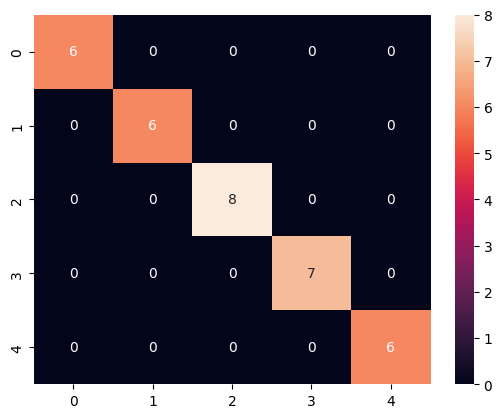

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, prediction)
sns.heatmap(cm, annot=True)


1/1 [==============================] - 0s 103ms/step
The prediction for this image is:  ['beagle']
The actual label for this image is:  beagle


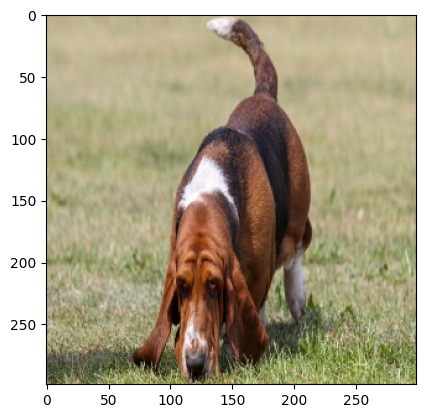

In [34]:
#Check results on a few select images
n=np.random.randint(0, x_test.shape[0])
img = x_test[n]
plt.imshow(img)
input_img = np.expand_dims(img, axis=0) #Expand dims so the input is (num images, x, y, c)
input_img_feature=Xception_model.predict(input_img)
input_img_features=input_img_feature.reshape(input_img_feature.shape[0], -1)
prediction_RF = voting_model.predict(input_img_features)[0]
prediction_RF = le.inverse_transform([prediction_RF])  #Reverse the label encoder to original name
print("The prediction for this image is: ", prediction_RF)
print("The actual label for this image is: ", test_labels[n])


## **Export Results**

In [35]:
import json

def save_metrics(model_name, configuration, acc, prec, rec, f1):
    save_dir_path = "model_metrics"
    
    metrics_dict = {"model": model_name,
        "configuration": configuration,
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
    }

    if not os.path.exists(save_dir_path):
        os.makedirs(save_dir_path, exist_ok=True)
    file_path = os.path.join(save_dir_path, f"{model_name}_{configuration}.json")
    with open(file_path, "w") as f: json.dump(metrics_dict, f, indent=4)
    print(f"Metrics saved to: {file_path}")


In [36]:
save_metrics(
    model_name="Xception",
    configuration="VotingClassifier",
    acc=accuracy,
    prec=precision,
    rec=recall,
    f1=f1,
)

Metrics saved to: model_metrics\Xception_VotingClassifier.json
